<a href="https://colab.research.google.com/github/mhmmdrdhiansyah/data-science-2026/blob/main/pertemuan7_muhammad_ardhiansyah_240401020092.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

nama : muhammad Ardhiansyah

nim : 240401020092

kelas : IF403

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Membuat data simulasi hubungan Pengalaman Kerja (Tahun) vs Gaji (Juta Rp)
np.random.seed(42)
pengalaman = np.random.uniform(1, 10, 100)
gaji = 3.5 + 2.1 * pengalaman + np.random.normal(0, 1.5, 100)

# Menggabungkan menjadi DataFrame Pandas
df_gaji = pd.DataFrame({
    'Pengalaman_Kerja': pengalaman,
    'Gaji_Juta': gaji
})

print("--- 5 Baris Pertama Dataset Gaji ---")
display(df_gaji.head())

--- 5 Baris Pertama Dataset Gaji ---


,Pengalaman_Kerja,Gaji_Juta
0,4.370861,12.809379
1,9.556429,23.119989
2,7.587945,19.572327
3,6.387926,13.933292
4,2.404168,8.219244


In [6]:
# Memisahkan Fitur (harus berbentuk 2D/DataFrame) dan Target (1D/Series)
X = df_gaji[['Pengalaman_Kerja']]
y = df_gaji['Gaji_Juta']

# Memisahkan menjadi data latih (Train) dan data uji (Test) dengan proporsi 80:20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Jumlah sampel Data Training : {X_train.shape[0]} baris")
print(f"Jumlah sampel Data Testing  : {X_test.shape[0]} baris")

Jumlah sampel Data Training : 80 baris
Jumlah sampel Data Testing  : 20 baris


In [7]:
# 1. Inisialisasi Objek Model
model_regresi = LinearRegression()

# 2. Melatih model menggunakan Data Latih (Training Set)
model_regresi.fit(X_train, y_train)

# Menampilkan parameter garis regresi yang berhasil dipelajari komputer
print(f"Nilasi Intercept (Beta 0) : {model_regresi.intercept_:.3f}")
print(f"Nilai Slope/Koefisien (Beta 1) : {model_regresi.coef_[0]:.3f}")
print("\nPersamaan Garis: Gaji = ", round(model_regresi.intercept_, 3), " + ", round(model_regresi.coef_[0], 3), " * Pengalaman")

Nilasi Intercept (Beta 0) : 3.781
Nilai Slope/Koefisien (Beta 1) : 2.033

Persamaan Garis: Gaji =  3.781  +  2.033  * Pengalaman


In [8]:
# Memprediksi nilai target dari dataset pengujian
y_pred = model_regresi.predict(X_test)

# Menampilkan perbandingan 5 data aktual vs hasil tebakan model
df_hasil = pd.DataFrame({
    'Pengalaman Kerja': X_test['Pengalaman_Kerja'].head(5),
    'Gaji Aktual': y_test.head(5),
    'Gaji Prediksi (Tebakan)': y_pred[:5]
})
print("--- Sampel Hasil Perbandingan Prediksi ---")
display(df_hasil.round(2))

--- Sampel Hasil Perbandingan Prediksi ---


,Pengalaman Kerja,Gaji Aktual,Gaji Prediksi (Tebakan)
83,1.57,7.79,6.98
53,9.05,21.76,22.19
70,7.95,18.34,19.94
45,6.96,16.76,17.94
44,3.33,11.68,10.55


In [9]:
# Menghitung metrik-metrik evaluasi regresi linear
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("--- Hasil Evaluasi Akurasi Model ---")
print(f"Mean Absolute Error (MAE)  : {mae:.3f} Juta Rp")
print(f"Mean Squared Error (MSE)   : {mse:.3f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.3f} Juta Rp")
print(f"R-Squared (R2 Score)       : {r2:.3f} ({r2*100:.1f}%)")

--- Hasil Evaluasi Akurasi Model ---
Mean Absolute Error (MAE)  : 0.887 Juta Rp
Mean Squared Error (MSE)   : 1.471
Root Mean Squared Error (RMSE): 1.213 Juta Rp
R-Squared (R2 Score)       : 0.955 (95.5%)


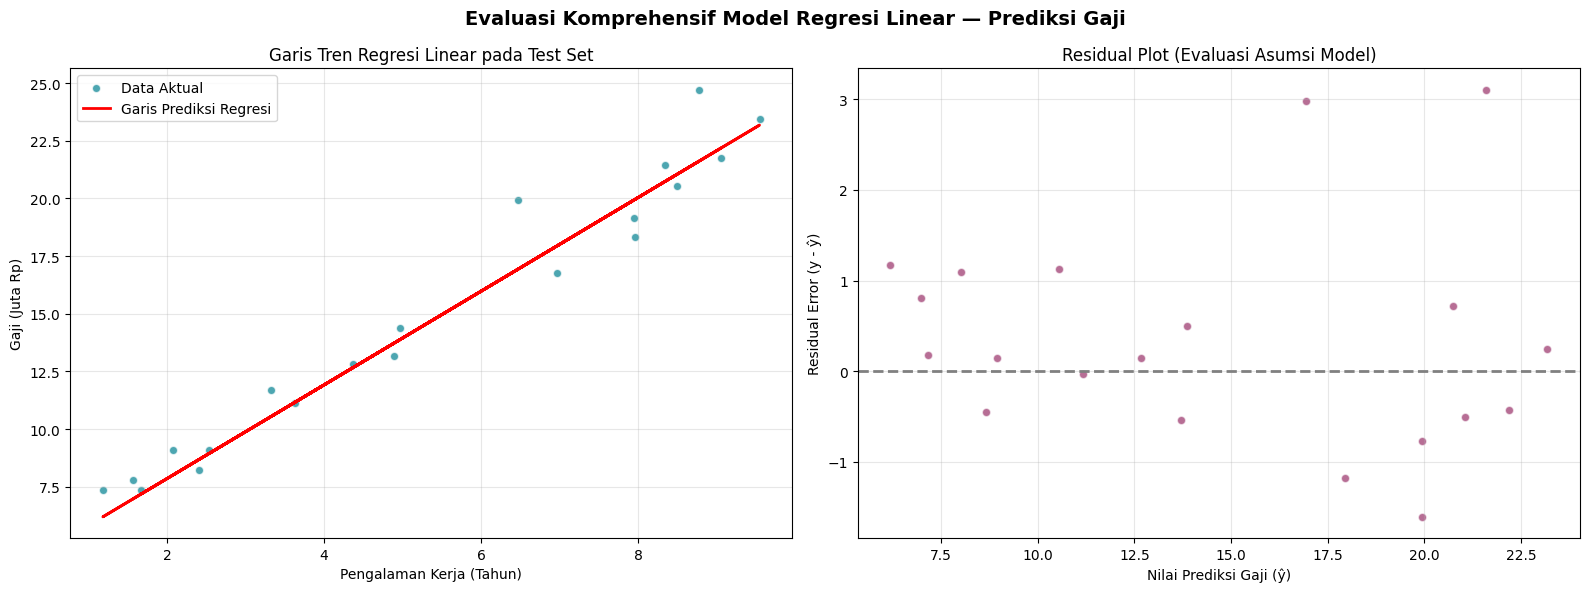

Dashboard evaluasi berhasil digambar dan disimpan sebagai 'evaluasi_regresi_gaji.png'!


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Garis Tren Linear Aktual vs Prediksi
axes[0].scatter(X_test, y_test, color='#028090', alpha=0.7, edgecolors='white', label='Data Aktual')
axes[0].plot(X_test, y_pred, color='red', linewidth=2, label='Garis Prediksi Regresi')
axes[0].set_xlabel('Pengalaman Kerja (Tahun)')
axes[0].set_ylabel('Gaji (Juta Rp)')
axes[0].set_title('Garis Tren Regresi Linear pada Test Set')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: Residual Plot (Error Sebaran)
sisa_error = y_test - y_pred
axes[1].scatter(y_pred, sisa_error, color='#880E4F', alpha=0.6, edgecolors='white')
axes[1].axhline(0, color='gray', linestyle='--', linewidth=2)
axes[1].set_xlabel('Nilai Prediksi Gaji (ŷ)')
axes[1].set_ylabel('Residual Error (y - ŷ)')
axes[1].set_title('Residual Plot (Evaluasi Asumsi Model)')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Evaluasi Komprehensif Model Regresi Linear — Prediksi Gaji', fontsize=14, fontweight='bold')
plt.tight_layout()

# Menyimpan hasil visualisasi evaluasi model
plt.savefig('evaluasi_regresi_gaji.png', dpi=150, bbox_inches='tight')
plt.show()
print("Dashboard evaluasi berhasil digambar dan disimpan sebagai 'evaluasi_regresi_gaji.png'!")

Melalui Modul 7 ini, saya beralih ke tahap implementasi kecerdasan buatan operasional (Machine Learning) dengan fokus pada pemodelan prediktif kuantitatif/kontinu menggunakan Regresi Linear Sederhana. saya mempelajari bagaimana sebuah algoritma "belajar" menemukan garis tren terbaik (Ordinary Least Squares) dari data latih. Lebih penting lagi, kita memahami arsitektur pemisahan Train-Test Split demi menjaga objektivitas pengujian model, menguasai cara membaca sisa error (Residual Plot), serta menguasai cara menginterpretasikan performa akurasi lewat nilai R-Squared guna mengukur seberapa besar persentase variasi target yang sukses dijelaskan oleh fitur prediktor kita.